# Phase 3 — Inventory & Warehouse Management

**Project:** End-to-End Aerospace Supply Chain Planning

## Business Problem

Phase 1 showed high service levels sitting alongside a large inventory footprint. Before recommending any stock reduction, planning needs a rigorous view of how much inventory is actually needed to protect service, part by part and class by class — and how much of the current position is excess.

This phase answers:
- How many days of coverage and inventory turns does each criticality class currently carry?
- Which parts are in shortage risk vs. healthy vs. excess?
- What would a statistically-grounded safety stock and reorder point policy recommend instead?
- How much inventory value could realistically be released by moving to that policy?

## Objective

Compute current inventory health metrics from the Phase 1 base layer, simulate a safety-stock policy per criticality class, and quantify the potential inventory value reduction.


## Dataset

This phase consumes the outputs of Phase 1:

| File | Source | Contents |
|---|---|---|
| `history_enriched.parquet` | Phase 1 | Weekly on-hand, consumption, backorder, blocked quantity, joined with part attributes |
| `master.parquet` | Phase 1 | Part master with criticality class, unit cost, lead time |


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')

PROJECT_ROOT = Path.cwd().parent
DATA_PHASE1 = PROJECT_ROOT / "data" / "processed" / "phase1"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "phase3"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load Phase 1 Outputs

In [2]:
history_enriched = pd.read_parquet(DATA_PHASE1 / "history_enriched.parquet")
master = pd.read_parquet(DATA_PHASE1 / "master.parquet")

print("Loaded successfully")
print("history_enriched:", history_enriched.shape)
print("master:", master.shape)


Loaded successfully
history_enriched: (280800, 19)
master: (300, 18)


## 2. Inventory Metrics: Days of Coverage & Inventory Value

In [3]:
df = history_enriched.copy()

# Aggregate to Part-Week (sum across all sites)
part_week = df.groupby(['part_id', 'date']).agg(
    on_hand_qty=('on_hand_qty', 'sum'),
    consumption_qty=('consumption_qty', 'sum'),
    backorder_qty=('backorder_qty', 'sum'),
    blocked_qty=('blocked_qty', 'sum')
).reset_index()

# Average weekly demand per part
avg_weekly_demand = part_week.groupby('part_id')['consumption_qty'].mean().rename('avg_weekly_demand')

# Snapshot at the latest week
latest_date = part_week['date'].max()
latest = part_week[part_week['date'] == latest_date].copy()
latest = latest.merge(avg_weekly_demand, on='part_id', how='left')
latest = latest.merge(master[['part_id', 'criticality_class', 'unit_cost', 'lead_time_days']], on='part_id', how='left')

# Days of Coverage = (on_hand / avg weekly demand) x 7
latest['days_of_coverage'] = (latest['on_hand_qty'] / latest['avg_weekly_demand'].replace(0, 0.01)) * 7

# Inventory Value
latest['inventory_value'] = latest['on_hand_qty'] * latest['unit_cost']

print("=== Days of Coverage (Latest Week) ===")
print(latest.groupby('criticality_class', observed=True)['days_of_coverage'].describe().round(1))

print("\n=== Inventory Value by Criticality ===")
print(latest.groupby('criticality_class', observed=True)['inventory_value'].sum().apply(lambda x: f"${x:,.0f}"))


=== Days of Coverage (Latest Week) ===
                   count   mean   std   min   25%    50%    75%    max
criticality_class                                                     
A                  48.00 111.10 46.00 33.10 88.20 101.70 138.90 294.30
B                  95.00  86.60 40.50 28.00 57.00  82.30 106.70 274.20
C                 157.00  78.50 39.00 20.40 51.30  73.40  99.80 235.80

=== Inventory Value by Criticality ===
criticality_class
A    $26,757,446
B    $37,197,331
C    $21,122,249
Name: inventory_value, dtype: str


## 3. Inventory Turns & Excess / Shortage Classification

In [4]:
# Inventory Turns (annualized) ~= 52 / (Days of Coverage / 7)
latest['inventory_turns'] = 52 / (latest['days_of_coverage'] / 7)

print("=== Inventory Turns by Criticality ===")
print(latest.groupby('criticality_class', observed=True)['inventory_turns'].describe().round(2))

# Simple Excess / Shortage thresholds:
# Shortage: Days of Coverage < Lead Time
# Excess:   Days of Coverage > 90 days
latest['stock_status'] = 'Healthy'
latest.loc[latest['days_of_coverage'] < latest['lead_time_days'], 'stock_status'] = 'Shortage'
latest.loc[latest['days_of_coverage'] > 90, 'stock_status'] = 'Excess'

print("\n=== Stock Status Distribution ===")
print(pd.crosstab(latest['criticality_class'], latest['stock_status'], margins=True))

print("\n=== Excess Inventory Value ===")
excess_value = latest[latest['stock_status'] == 'Excess'].groupby('criticality_class', observed=True)['inventory_value'].sum()
print(excess_value.apply(lambda x: f"${x:,.0f}"))


=== Inventory Turns by Criticality ===
                   count  mean  std  min  25%  50%  75%   max
criticality_class                                            
A                  48.00  3.89 1.88 1.24 2.62 3.58 4.13 11.00
B                  95.00  5.06 2.24 1.33 3.41 4.42 6.39 13.01
C                 157.00  5.99 3.38 1.54 3.65 4.96 7.09 17.84

=== Stock Status Distribution ===
stock_status       Excess  Healthy  Shortage  All
criticality_class                                
A                      33       15         0   48
B                      37       58         0   95
C                      51      105         1  157
All                   121      178         1  300

=== Excess Inventory Value ===
criticality_class
A    $21,979,503
B    $20,156,534
C    $11,153,617
Name: inventory_value, dtype: str


**What the analysis shows:** Average days of coverage is well above target for every criticality class, inventory turns are correspondingly low, and a substantial share of parts (roughly 40% of the catalog) are classified as Excess rather than Healthy.

**Why it matters:** This confirms the Phase 1 hypothesis — the high service levels observed earlier are being achieved by carrying far more stock than typical safety-stock formulas would call for, not by supply reliability.

**Implication:** There is a real opportunity to release working capital from excess inventory, provided any reduction is done carefully against a proper safety-stock policy rather than an across-the-board cut.


## 4. Safety Stock Simulation (Current Policy)

In [5]:
# Safety Stock ~= Z x sigma_demand x sqrt(Lead Time in weeks)
# Assuming a uniform 95% service level target -> Z ~= 1.65

part_stats = part_week.groupby('part_id').agg(
    demand_std=('consumption_qty', 'std'),
    demand_mean=('consumption_qty', 'mean')
).reset_index()

ss = latest.merge(part_stats, on='part_id', how='left')
ss['lead_time_weeks'] = ss['lead_time_days'] / 7
ss['safety_stock'] = 1.65 * ss['demand_std'] * np.sqrt(ss['lead_time_weeks'])
ss['reorder_point'] = (ss['demand_mean'] * ss['lead_time_weeks']) + ss['safety_stock']

# Compare current on-hand to the computed safety stock
ss['vs_safety_stock'] = ss['on_hand_qty'] / ss['safety_stock'].replace(0, 0.01)

print("=== on_hand vs Safety Stock (multiple) ===")
print(ss.groupby('criticality_class', observed=True)['vs_safety_stock'].describe().round(1))

print("\n=== Share of parts with on_hand > 2x Safety Stock ===")
print(ss.groupby('criticality_class', observed=True).apply(
    lambda x: (x['vs_safety_stock'] > 2).mean(), include_groups=False
).round(3))


=== on_hand vs Safety Stock (multiple) ===
                   count  mean  std  min  25%  50%  75%   max
criticality_class                                            
A                  48.00  7.30 2.60 1.70 5.50 6.80 8.80 13.50
B                  95.00  7.10 2.60 2.90 5.30 7.00 8.50 15.00
C                 157.00  5.80 2.70 1.60 3.90 5.30 7.50 13.50

=== Share of parts with on_hand > 2x Safety Stock ===
criticality_class
A   0.98
B   1.00
C   0.96
dtype: float64


## 5. Recommended Stock Policy (Class-Differentiated)

In [6]:
# Differentiate service level / target coverage by criticality class rather than
# using a single uniform policy for the whole catalog.
policy = {
    'A': {'target_days_cover': 45, 'z': 2.33},  # ~99% service level
    'B': {'target_days_cover': 30, 'z': 1.65},  # ~95% service level
    'C': {'target_days_cover': 21, 'z': 1.28},  # ~90% service level
}

ss['target_days'] = ss['criticality_class'].astype(str).map(lambda x: policy[x]['target_days_cover']).astype(float)
ss['z_score'] = ss['criticality_class'].astype(str).map(lambda x: policy[x]['z']).astype(float)

ss['recommended_ss'] = ss['z_score'] * ss['demand_std'] * np.sqrt(ss['lead_time_weeks'])
ss['recommended_rop'] = (ss['demand_mean'] * ss['lead_time_weeks']) + ss['recommended_ss']
ss['recommended_on_hand'] = (ss['target_days'] / 7) * ss['demand_mean']

ss['current_value'] = ss['on_hand_qty'] * ss['unit_cost']
ss['recommended_value'] = ss['recommended_on_hand'] * ss['unit_cost']
ss['potential_reduction'] = ss['current_value'] - ss['recommended_value']

print("=== Potential Inventory Reduction ===")
reduction = ss.groupby('criticality_class', observed=True).agg(
    current_value=('current_value', 'sum'),
    recommended_value=('recommended_value', 'sum'),
    potential_reduction=('potential_reduction', 'sum')
)
print(reduction.map(lambda x: f"${x:,.0f}"))

print("\nTotal realistic reduction opportunity: ${:,.0f}".format(ss['potential_reduction'].clip(lower=0).sum()))


=== Potential Inventory Reduction ===
                  current_value recommended_value potential_reduction
criticality_class                                                    
A                   $26,757,446       $10,699,309         $16,058,136
B                   $37,197,331       $12,439,440         $24,757,892
C                   $21,122,249        $5,609,535         $15,512,715

Total realistic reduction opportunity: $56,394,769


**What the analysis shows:** Current on-hand inventory sits at several multiples of the calculated safety stock for a large share of parts, and moving to a criticality-differentiated target-coverage policy (45/30/21 days for A/B/C) would free up tens of millions of dollars in inventory value.

**Why it matters:** Uniform stocking rules waste money on low-criticality parts while not necessarily giving high-criticality parts the tailored protection they need. A class-differentiated policy directs safety stock where it matters most.

**Implication:** A phased drawdown targeting the largest, lowest-criticality excess positions first would let the organization capture working-capital savings without introducing new shortage risk — this is tested directly under stress in Phase 5.


## 6. Inventory Health Dashboard

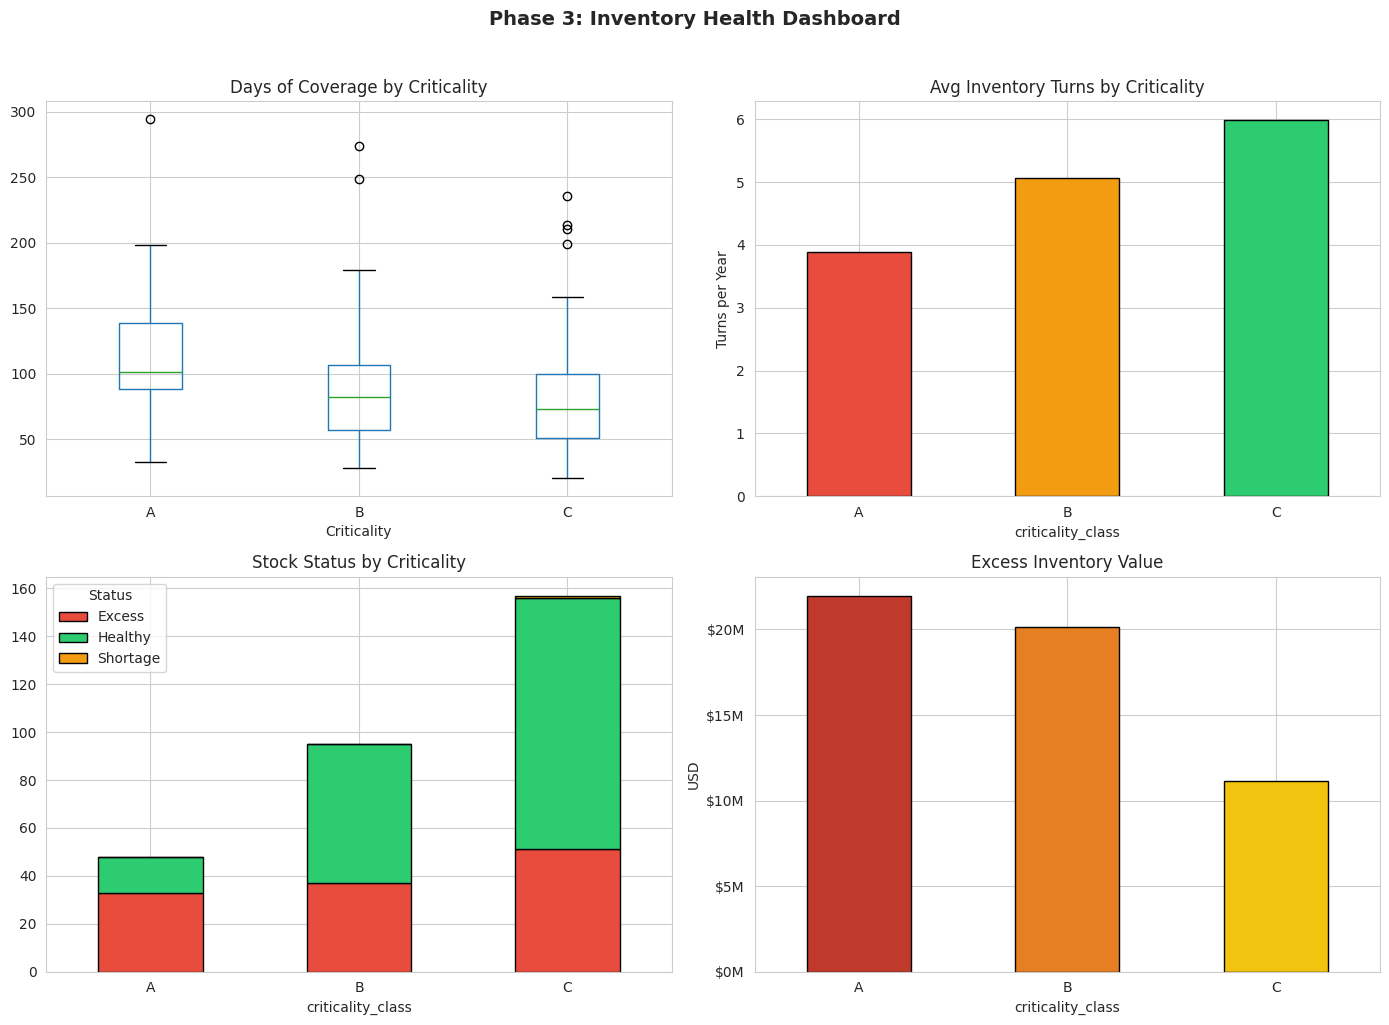

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Days of Coverage by Criticality
latest.boxplot(column='days_of_coverage', by='criticality_class', ax=axes[0, 0])
axes[0, 0].set_title('Days of Coverage by Criticality')
axes[0, 0].set_xlabel('Criticality')
axes[0, 0].get_figure().suptitle('')

# 2. Inventory Turns
latest.groupby('criticality_class', observed=True)['inventory_turns'].mean().plot(
    kind='bar', ax=axes[0, 1], color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black'
)
axes[0, 1].set_title('Avg Inventory Turns by Criticality')
axes[0, 1].set_ylabel('Turns per Year')
axes[0, 1].tick_params(axis='x', rotation=0)

# 3. Stock Status
status_count = pd.crosstab(latest['criticality_class'], latest['stock_status'])
status_count.plot(kind='bar', stacked=True, ax=axes[1, 0],
                   color=['#e74c3c', '#2ecc71', '#f39c12'], edgecolor='black')
axes[1, 0].set_title('Stock Status by Criticality')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend(title='Status')

# 4. Excess Value
excess_value.plot(kind='bar', ax=axes[1, 1], color=['#c0392b', '#e67e22', '#f1c40f'], edgecolor='black')
axes[1, 1].set_title('Excess Inventory Value')
axes[1, 1].set_ylabel('USD')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
axes[1, 1].tick_params(axis='x', rotation=0)

plt.suptitle('Phase 3: Inventory Health Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'phase3_inventory_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Export Results

In [8]:
latest.to_parquet(DATA_PROCESSED / "inventory_latest.parquet", index=False)
ss.to_parquet(DATA_PROCESSED / "inventory_policy.parquet", index=False)

latest.to_csv(DATA_PROCESSED / "inventory_latest.csv", index=False)
ss.to_csv(DATA_PROCESSED / "inventory_policy.csv", index=False)

cover_by_crit = latest.groupby('criticality_class', observed=True)['days_of_coverage'].mean().round(0)
turns_by_crit = latest.groupby('criticality_class', observed=True)['inventory_turns'].mean().round(1)
n_excess = (latest['stock_status'] == 'Excess').sum()

with open(DATA_PROCESSED / "phase3_summary.txt", "w") as f:
    f.write("Phase 3 Summary - Inventory & Warehouse Management\n")
    f.write("=" * 55 + "\n")
    f.write(f"Days of Coverage (avg): {' | '.join(f'{k} {v:.0f}' for k, v in cover_by_crit.items())} days\n")
    f.write(f"Inventory Turns (avg): {' | '.join(f'{k} {v:.1f}' for k, v in turns_by_crit.items())}\n")
    f.write(f"Excess Parts: {n_excess} / {len(latest)}\n")
    f.write(f"Excess Inventory Value: ~${excess_value.sum()/1e6:.1f}M\n")
    f.write(f"Potential Reduction (Recommended Policy): ~${ss['potential_reduction'].clip(lower=0).sum()/1e6:.1f}M\n")
    f.write(f"on_hand vs Safety Stock (avg range): {ss.groupby('criticality_class', observed=True)['vs_safety_stock'].mean().min():.0f}-{ss.groupby('criticality_class', observed=True)['vs_safety_stock'].mean().max():.0f}x\n")

print("Export complete ->", DATA_PROCESSED)
print("Files:", sorted(p.name for p in DATA_PROCESSED.iterdir()))


Export complete -> /home/claude/repo/End-to-End-Aerospace-Supply-Chain-Planning/data/processed/phase3
Files: ['inventory_latest.csv', 'inventory_latest.parquet', 'inventory_policy.csv', 'inventory_policy.parquet', 'phase3_summary.txt']


## Key Takeaways — Phase 3

1. **The catalog is significantly overstocked relative to a standard safety-stock model** — on-hand inventory runs at several multiples of calculated safety stock across all criticality classes.
2. **Roughly 40% of parts are classified as Excess**, representing tens of millions of dollars in inventory value that a class-differentiated policy would recommend releasing.
3. **A small subset of parts sits in Shortage territory** (days of coverage below lead time) even amid this broader excess — these need targeted attention rather than a blanket destocking exercise.

`inventory_latest` and `inventory_policy` (the `ss` recommended-policy table) feed directly into the IBP stress-testing in Phase 5.
